### Import

In [664]:
import numpy as np
import scipy.ndimage as ndimage
import matplotlib.pyplot as plt
import os

### Load Img

In [665]:
# Use an absolute path to the image file
image_path = os.path.abspath('images/primer_0.25_pi_rad.png')

# Load the image
slika = plt.imread(image_path)[:, :, :3]

# Convert to grayscale by averaging the RGB channels
slika = slika.mean(2)

### Apply Gaussian filter

In [667]:
#apply gaussian filter from ndimage library
slika_conv_gaussian = ndimage.gaussian_filter(slika, sigma=20)

"""
sigma = 1.0
velikost_jedra = int(3*sigma)
# koordinate jedra po x dimenziji
x = np.arange(-velikost_jedra, velikost_jedra+1)
# koordinate jedra v obeh dimenzijah v 2d matrikah
X, Y = np.meshgrid(x, x)
jedro_tocke = np.array([X.ravel(), Y.ravel()]) # 2 x P
C = np.eye(2)*1/sigma**2

jedro_gauss = np.exp(-1*(jedro_tocke.T.dot(C)*jedro_tocke.T).sum(1)).reshape(X.shape)

slika_conv_gaussian = ndimage.convolve(slika, jedro_gauss, mode='constant', cval=0.0)
plt.imshow(slika)
"""

"\nsigma = 1.0\nvelikost_jedra = int(3*sigma)\n# koordinate jedra po x dimenziji\nx = np.arange(-velikost_jedra, velikost_jedra+1)\n# koordinate jedra v obeh dimenzijah v 2d matrikah\nX, Y = np.meshgrid(x, x)\njedro_tocke = np.array([X.ravel(), Y.ravel()]) # 2 x P\nC = np.eye(2)*1/sigma**2\n\njedro_gauss = np.exp(-1*(jedro_tocke.T.dot(C)*jedro_tocke.T).sum(1)).reshape(X.shape)\n\nslika_conv_gaussian = ndimage.convolve(slika, jedro_gauss, mode='constant', cval=0.0)\nplt.imshow(slika)\n"

In [668]:
f=np.zeros((31, 31))
f[0, 0] = 1

slika_filt = ndimage.convolve(slika_conv_gaussian, f, mode='constant', cval=0)

### Apply Sobel filter 
### Make magnitude

In [669]:
jedro_sobel_dx = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])
jedro_sobel_dy = np.array([
    [1,  2,  1],
    [0,  0,  0],
    [-1, -2, -1]
])

slika_dx = ndimage.convolve(slika_conv_gaussian, jedro_sobel_dx, mode='constant', cval=0.0)
slika_dy = ndimage.convolve(slika_conv_gaussian, jedro_sobel_dy, mode='constant', cval=0.0)
# slika_dx_and_dy = ndimage.convolve(slika_dx, jedro_sobel_dy, mode='constant', cval=0.0)
#"""
slika_rob_mag = (slika_dx**2 + slika_dy**2)**0.5 # samo pitagorov izrek
# slika_rob_smer = np.arctan2(slika_dy, slika_dx)
slika_rob_smer = np.arctan2(slika_dy, slika_dx)

# Apply Sobel filters to the image
slika_sobel_dx = ndimage.convolve(slika_conv_gaussian, jedro_sobel_dx, mode='constant', cval=0.0)
slika_sobel_dy = ndimage.convolve(slika_conv_gaussian, jedro_sobel_dy, mode='constant', cval=0.0)

# Compute the magnitude of the gradient
slika_sobel = np.hypot(slika_sobel_dx, slika_sobel_dy)

# Normalize the result
slika_sobel = (slika_sobel / slika_sobel.max()) * 255  # Scale to 0-255

# Convert to unsigned 8-bit integer type for proper image representation
slika_sobel = slika_sobel.astype(np.uint8)

### Correct edges

### Make histogram
#### Apply magnitude to histogram as weights

In [670]:
# razdelimo histogram na 16 predalckov med vrednostmi -pi, pi
hist_bins = np.linspace(-np.pi, np.pi, 17)
# razdelimo piksle v predalcke po kotu roba, pomnozeno z weightom magnitude ki nam pove kak mocn je rob
hist_smeri_x, hist_smeri_y = np.histogram(slika_rob_smer, bins=hist_bins, weights=slika_rob_mag)

# Find the maximum value on the y-axis (histogram counts)
max_y = np.max(hist_smeri_x)

# Find the index of the maximum value
max_y_index = np.argmax(hist_smeri_x)

# Find the corresponding bin edge (x-axis)
max_x = hist_bins[max_y_index]

# Find the center of the bin with the highest count
max_bin_center = (hist_bins[max_y_index] + hist_bins[max_y_index + 1]) / 2

# Convert the bin center value from radians to degrees
max_bin_degrees = np.degrees(max_x)

## Show histogram and filtered image
## Print out angle

Maximum value on the x-axis (bin edge): -0.39269908169872414
Maximum value on the y-axis: 294.5364990234375
Maximum bin center value in radians: -0.39269908169872414
Maximum bin center value in degrees: -22.5
Average value of x: -0.19634954084936207
Average value of y: 81.51734161376953
Maximum value on the x-axis (bin edge): -0.39269908169872414
Maximum value on the y-axis: 294.5364990234375
Maximum bin center value in radians: -0.39269908169872414
Maximum bin center value in degrees: -22.5
Second largest value on the y-axis: 293.05548095703125
Corresponding bin edge for the second largest value: 1.5707963267948966
Angle: 0.5890486225480862
Val: 293.05548095703125


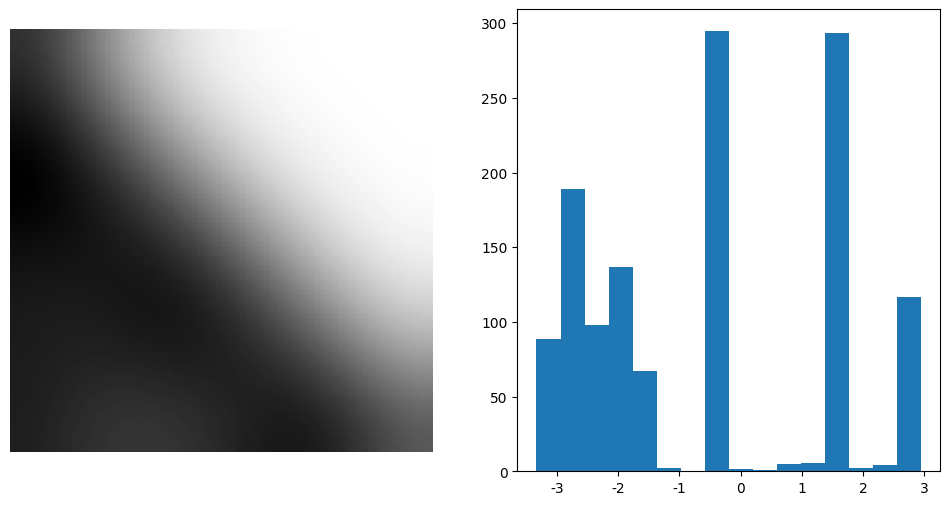

In [671]:
print(f"Maximum value on the x-axis (bin edge): {max_x}")
print(f"Maximum value on the y-axis: {max_y}")
print(f"Maximum bin center value in radians: {max_x}")
print(f"Maximum bin center value in degrees: {max_bin_degrees}")

# Calculate the average values of x and y
average_x = np.mean(hist_bins[:-1])
average_y = np.mean(hist_smeri_x)

print(f"Average value of x: {average_x}")
print(f"Average value of y: {average_y}")

# Find the second largest value in the histogram counts
sorted_hist_smeri_x = np.sort(hist_smeri_x)[::-1]  # Sort in descending order
second_largest_y = sorted_hist_smeri_x[1]  # Second largest value

# Find the corresponding bin edge for the second largest value
second_largest_y_index = np.where(hist_smeri_x == second_largest_y)[0][0]
second_largest_x = hist_bins[second_largest_y_index]


print(f"Maximum value on the x-axis (bin edge): {max_x}")
print(f"Maximum value on the y-axis: {max_y}")
print(f"Maximum bin center value in radians: {max_x}")
print(f"Maximum bin center value in degrees: {max_bin_degrees}")

print(f"Second largest value on the y-axis: {second_largest_y}")
print(f"Corresponding bin edge for the second largest value: {second_largest_x}")

print(f"Angle: {(second_largest_x + max_x) * 0.5}")
print(f"Val: {second_largest_y}")



#max_y = x[np.where(hist_smeri_y == hist_smeri_y.max())]
#print(f"Maximum: {hist_bins[max_y]}")


# Plot the image and histogram
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(slika_conv_gaussian, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
# 16 bins, count is height, width is the difference between two edges
plt.bar(hist_bins[:-1], hist_smeri_x, width=hist_bins[2] - hist_bins[1])

# Set x-ticks to -3, -2, -1, 0, 1, 2, 3
plt.xticks(ticks=np.linspace(-3, 3, 7), labels=['-3', '-2', '-1', '0', '1', '2', '3'])

plt.show()

#### Old show graph code

In [647]:
"""
# Display the original and the blurred image
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title('Original img')
plt.imshow(slika, cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Filtered img')
plt.imshow(slika_sobel, cmap='gray')
plt.axis('off')

plt.show()
"""

"\n# Display the original and the blurred image\nplt.figure(figsize=(12, 6))\n\nplt.subplot(1, 2, 1)\nplt.title('Original img')\nplt.imshow(slika, cmap='gray')\nplt.axis('off')\n\nplt.subplot(1, 2, 2)\nplt.title('Filtered img')\nplt.imshow(slika_sobel, cmap='gray')\nplt.axis('off')\n\nplt.show()\n"